# 03. LSTM 감성분류기 학습 (비교군)

직접 학습하는 LSTM 베이스라인. DistilBERT와 같은 데이터·지표(Accuracy/F1)로 비교한다.

산출물: `models/lstm/{model.pt, vocab.json, metrics.json}`

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import json
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from src.config import DATA_DIR, MODEL_DIR, OUTPUT_DIR, MAX_LEN, RANDOM_SEED
from src.models.dataset import build_vocab, encode
from src.models.lstm import LSTMClassifier

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EPOCHS = 3
torch.manual_seed(RANDOM_SEED)

In [2]:
tr = pd.read_csv(DATA_DIR / "train.csv")
te = pd.read_csv(DATA_DIR / "test.csv")
vocab = build_vocab(tr["text"].tolist())
print(f"train={len(tr)} test={len(te)} vocab={len(vocab):,}")

train=11498 test=2464 vocab=15,736


In [3]:
def tensors(df, vocab):
    X = torch.tensor([encode(t, vocab, MAX_LEN) for t in df["text"]])
    y = torch.tensor(df["label"].tolist())
    return TensorDataset(X, y)

dl = DataLoader(tensors(tr, vocab), batch_size=64, shuffle=True)
model = LSTMClassifier(len(vocab))
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = torch.nn.CrossEntropyLoss()

batch_losses, epoch_losses = [], []
for ep in range(EPOCHS):
    model.train()
    total = 0.0
    for X, y in dl:
        opt.zero_grad()
        loss = loss_fn(model(X), y)
        loss.backward()
        opt.step()
        batch_losses.append(loss.item())
        total += loss.item() * len(y)
    epoch_losses.append(total / len(tr))
    print(f"epoch {ep + 1}/{EPOCHS} — avg loss {epoch_losses[-1]:.4f}")

epoch 1/3 — avg loss 0.4812
epoch 2/3 — avg loss 0.4657
epoch 3/3 — avg loss 0.4598


In [4]:
model.eval()
Xte = torch.tensor([encode(t, vocab, MAX_LEN) for t in te["text"]])
with torch.no_grad():
    preds = model(Xte).argmax(1).tolist()

result = {"accuracy": accuracy_score(te["label"], preds),
          "f1": f1_score(te["label"], preds)}
print("LSTM test:", result)
print("confusion matrix:\n", confusion_matrix(te["label"], preds))

LSTM test: {'accuracy': 0.8189935064935064, 'f1': 0.9003574620196604}
confusion matrix:
 [[   3  439]
 [   7 2015]]


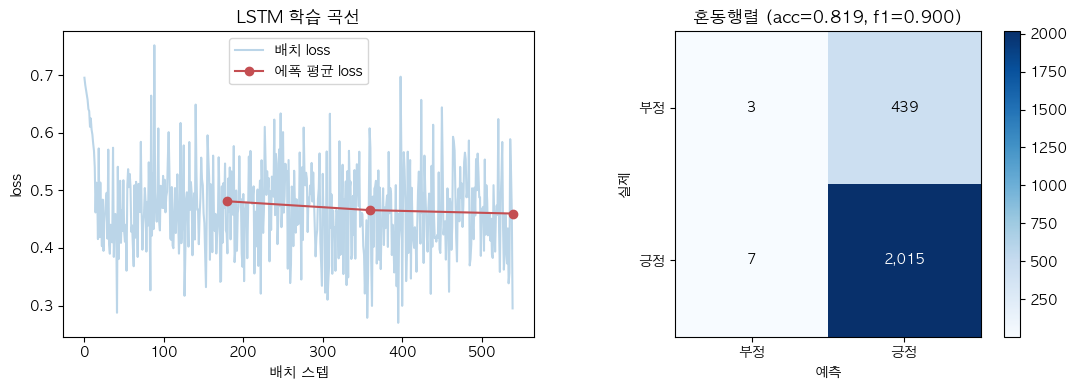

In [5]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(batch_losses, alpha=0.3, label="배치 loss")
steps_per_epoch = len(batch_losses) // EPOCHS
ax1.plot([steps_per_epoch * (i + 1) - 1 for i in range(EPOCHS)],
         epoch_losses, "o-", color="#c44e52", label="에폭 평균 loss")
ax1.set_title("LSTM 학습 곡선")
ax1.set_xlabel("배치 스텝")
ax1.set_ylabel("loss")
ax1.legend()

cm = confusion_matrix(te["label"], preds)
im = ax2.imshow(cm, cmap="Blues")
ax2.set_xticks([0, 1], ["부정", "긍정"])
ax2.set_yticks([0, 1], ["부정", "긍정"])
ax2.set_xlabel("예측")
ax2.set_ylabel("실제")
ax2.set_title(f"혼동행렬 (acc={result['accuracy']:.3f}, f1={result['f1']:.3f})")
for i in range(2):
    for j in range(2):
        ax2.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.colorbar(im, ax=ax2)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "03_lstm_loss_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
out = MODEL_DIR / "lstm"
out.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), out / "model.pt")
(out / "vocab.json").write_text(json.dumps(vocab))
(out / "metrics.json").write_text(json.dumps(result, indent=2))
print(f"saved → {out}")

saved → /Users/gomuseo/Desktop/Python/review-check/models/lstm
